# LAB 2


## LIBRARIES

In [141]:
import numpy as np
from enum import Enum
from collections import deque
import matplotlib.pyplot as plt

## CLASSES

### TASKCLASS

In [142]:


class TaskClass(Enum):
    """Enum to distinguish between delay-sensitive and delay-tolerant task classes"""
    DELAY_SENSITIVE = "delay_sensitive"      # Ks - low latency requirement
    DELAY_TOLERANT = "delay_tolerant"        # Kt - high latency tolerance


### TASK

In [ ]:
class Task:
    """
    Represents a computational task in the HAPS-edge computing system.
    
    Each task is characterized by three main parameters:
    - L: input data size [bits] - amount of data to be transmitted/processed
    - C: computational demand [CPU cycles] - processing effort required
    - Dmax: latency constraint [seconds] - maximum acceptable completion time
    
    Tasks belong to one of two classes with different characteristics:
    - Delay-sensitive (Ks): real-time monitoring services with strict latency requirements
    - Delay-tolerant (Kt): background processing with flexible latency constraints
    
    All parameters are generated from exponential distributions, allowing
    heterogeneous and realistic task characteristics.
    """
    
    # Task class parameter configurations
    # Format: {"mean_L": mean_bits, "mean_C": mean_cycles}
    # Note: Dmax is generated from a constant mean (0.5 sec) independent of task class
    TASK_PARAMS = {
        TaskClass.DELAY_SENSITIVE: {
            "mean_L": 1e4,          # 10 kbits - smaller data (real-time events)
            "mean_C": 1e6           # 1M cycles - moderate computation
        },
        TaskClass.DELAY_TOLERANT: {
            "mean_L": 1e5,          # 100 kbits - larger data (batch processing)
            "mean_C": 1e7           # 10M cycles - more demanding computation
        }
    }
    
    def __init__(self, dmax_threshold=0.5, custom_means=None, random_seed=None):
        """
        Initialize a Task instance.
        
        The task class (DELAY_SENSITIVE or DELAY_TOLERANT) is determined dynamically
        based on the generated latency constraint (Dmax) compared to a threshold.
        
        Parameters
        ----------
        dmax_threshold : float, optional
            Threshold value in seconds for classifying tasks. If generated Dmax > dmax_threshold,
            the task is classified as DELAY_TOLERANT; otherwise as DELAY_SENSITIVE.
            Default: 1.0 second
        custom_means : dict, optional
            Custom mean values for parameters. If provided, overrides defaults.
            Format: {"mean_L": value, "mean_C": value}
        random_seed : int, optional
            Seed for reproducibility of random number generation
        
        Returns
        -------
        None
        """
        
        # Set random seed if provided
        if random_seed is not None:
            np.random.seed(random_seed)
        
        # Validate threshold
        if dmax_threshold <= 0:
            raise ValueError(f"dmax_threshold must be positive, got {dmax_threshold}")
        
        self.dmax_threshold = dmax_threshold
        
        # Step 1: Generate Dmax from exponential distribution with mean 1.5 seconds
        # This ensures most tasks will have Dmax > threshold (0.5), making them DELAY_TOLERANT
        # P(Dmax > 0.5) = exp(-0.5/1.5) ≈ 0.717 (≈72% will be TOLERANT class)
        CONSTANT_DMAX_MEAN = 1.5  # seconds - mean of exponential distribution
        self.Dmax = np.random.exponential(CONSTANT_DMAX_MEAN)
        
        # Step 2: Classify task based on Dmax compared to threshold
        # If Dmax > threshold: DELAY_TOLERANT (flexible deadline)
        # If Dmax <= threshold: DELAY_SENSITIVE (strict deadline)
        if self.Dmax > dmax_threshold:
            self.task_class = TaskClass.DELAY_TOLERANT
        else:
            self.task_class = TaskClass.DELAY_SENSITIVE
        
        # Step 3: Get parameter means based on determined task class
        if custom_means is not None:
            params = custom_means
        else:
            params = self.TASK_PARAMS[self.task_class].copy()
        
        # Extract means for exponential distribution
        mean_L = params.get("mean_L", self.TASK_PARAMS[self.task_class]["mean_L"])
        mean_C = params.get("mean_C", self.TASK_PARAMS[self.task_class]["mean_C"])
        
        # Step 4: Generate remaining task parameters from exponential distributions
        # Exponential distribution: if X ~ Exp(λ), then mean = 1/λ
        # numpy uses scale parameter (λ^-1 = mean)
        self.L = np.random.exponential(mean_L)        # Input data size [bits]
        self.C = np.random.exponential(mean_C)        # Computational demand [CPU cycles]
    
    def __repr__(self):
        """String representation of the task for debugging and logging"""
        return (f"Task(class={self.task_class.value}, "
                f"L={self.L:.2e} bits, "
                f"C={self.C:.2e} cycles, "
                f"Dmax={self.Dmax:.4f} s)")
    
    def __str__(self):
        """Human-readable string representation"""
        return (f"\n{'='*60}\n"
                f"Task Details:\n"
                f"  Task Class: {self.task_class.value}\n"
                f"  Input Data Size (L): {self.L:.2e} bits\n"
                f"  Computational Demand (C): {self.C:.2e} CPU cycles\n"
                f"  Latency Constraint (Dmax): {self.Dmax:.4f} seconds\n"
                f"{'='*60}")
    
    def to_dict(self):
        """Convert task to dictionary format for easy storage/analysis"""
        return {
            "task_class": self.task_class.value,
            "L_bits": self.L,
            "C_cycles": self.C,
            "Dmax_seconds": self.Dmax
        }


### QUEUE

In [144]:


class Queue:
    """
    Represents a processing queue in the HAPS-edge computing system.
    
    The queue manages Task objects with a given arrival rate and computational capacity.
    Each task in the queue has a service time calculated as C/fs, where:
    - C: computational demand of the task [CPU cycles]
    - fs: computational capacity of the queue [CPU cycles/second]
    
    Attributes
    ----------
    lambda_arrival : float
        Task arrival rate [tasks/second] - average number of tasks arriving per unit time
    fs : float
        Computational capacity of the queue [CPU cycles/second]
        Represents the processing speed of the server(s) in the queue
    tasks : deque
        FIFO buffer storing Task objects waiting for or being processed
    """
    
    def __init__(self, lambda_arrival, fs, max_buffer_size=None):
        """
        Initialize a Queue instance.
        
        Parameters
        ----------
        lambda_arrival : float
            Task arrival rate in [tasks/second]. Must be positive.
        fs : float
            Computational capacity of the queue in [CPU cycles/second]. Must be positive.
        max_buffer_size : int, optional
            Maximum number of tasks the queue can hold. If None, queue is unlimited.
            Default: None (unlimited)
        
        Returns
        -------
        None
        """
        
        # Validate input parameters
        if lambda_arrival <= 0:
            raise ValueError(f"lambda_arrival must be positive, got {lambda_arrival}")
        if fs <= 0:
            raise ValueError(f"fs must be positive, got {fs}")
        if max_buffer_size is not None and max_buffer_size <= 0:
            raise ValueError(f"max_buffer_size must be positive, got {max_buffer_size}")
        
        self.lambda_arrival = lambda_arrival           # Arrival rate [tasks/sec]
        self.fs = fs                                   # Computational capacity [cycles/sec]
        self.max_buffer_size = max_buffer_size         # Maximum buffer capacity
        self.tasks = deque()                           # FIFO buffer for tasks
    
    def get_service_rate(self, task):
            return task.C / self.fs
    
    def enqueue(self, task):
        """
        Add a task to the queue buffer.

        """
        
        if not isinstance(task, Task):
            raise TypeError(f"Expected Task instance, got {type(task)}")
        
        # Check if buffer is full (if max_buffer_size is set)
        if self.max_buffer_size is not None and len(self.tasks) >= self.max_buffer_size:
            return False  # Enqueue failed - buffer full
        
        self.tasks.append(task)
        return True  # Enqueue successful
    
    def dequeue(self):
        """
        Remove and return the first task from the queue (FIFO).
        
        """
        if len(self.tasks) == 0:
            return None
        return self.tasks.popleft()
    
    def peek(self):
        """
        View the first task without removing it (peek operation).
        
        """
        if len(self.tasks) == 0:
            return None
        return self.tasks[0]
    
    def is_empty(self):
        """
        Check if the queue is empty.
        
        """
        return len(self.tasks) == 0
    
    def is_full(self):
        """
        Check if the queue buffer is full.
        
        """
        if self.max_buffer_size is None:
            return False
        return len(self.tasks) >= self.max_buffer_size
    
    def get_queue_length(self):
        """
        Get the current number of tasks in the queue.
        
        """
        return len(self.tasks)
    
    def get_utilization(self):
        """
        Get the queue buffer utilization (percentage filled).
        
        """
        if self.max_buffer_size is None:
            return None
        return (len(self.tasks) / self.max_buffer_size) * 100 if self.max_buffer_size > 0 else 0
    
    def __repr__(self):
        """String representation of the queue for debugging"""
        return (f"Queue(lambda={self.lambda_arrival}, fs={self.fs}, "
                f"buffer_size={self.get_queue_length()}/{self.max_buffer_size if self.max_buffer_size else 'unlimited'})")
    
    def __str__(self):
        """Human-readable string representation"""
        utilization = self.get_utilization()
        util_str = f"{utilization:.1f}%" if utilization is not None else "unlimited"
        
        return (f"\n{'='*70}\n"
                f"Queue Details:\n"
                f"  Arrival Rate (λ):          {self.lambda_arrival:.4f} tasks/sec\n"
                f"  Computational Capacity (fs): {self.fs:.2e} cycles/sec\n"
                f"  Current Queue Length:      {self.get_queue_length()} tasks\n"
                f"  Buffer Utilization:        {util_str}\n"
                f"  Queue Status:              {'EMPTY' if self.is_empty() else 'ACTIVE' if not self.is_full() else 'FULL'}\n"
                f"{'='*70}")

### SENSING_NODES_SIMULATOR

In [170]:
class SensingNodeSimulator:
    """
    Simulates a single sensing node with local processing using discrete event simulation.

    Queue discipline: FIFO (first-in-first-out).

    Events:
    - ARRIVAL: a new Task is generated and either starts service (if server idle)
               or is appended to the waiting queue.
    - DEPARTURE: the task in service completes; the next waiting task (if any)
                 is taken from the queue and served.

    Model choices (coherent parametrization with fixed fs):
    - Inter-arrival times are exponential with mean 1/lambda_arrival (Poisson arrivals).
    - Service time is exponential with mean (C/fs) for each task, i.e.:
        S | C  ~ Exp(rate = fs/C)  <=>  mean(S|C) = C/fs
      In numpy this is: np.random.exponential(scale = C/fs).

    Note: since C is already random (exponential by class), using an exponential
    service time with mean C/fs introduces additional variability (not a pure M/M/1),
    but it matches the intended "random service around C/fs" design.
    """

    def __init__(self, lambda_arrival, fs, dmax_threshold=0.5, random_seed=None):
        if random_seed is not None:
            np.random.seed(random_seed)

        self.lambda_arrival = float(lambda_arrival)
        self.fs = float(fs)
        self.dmax_threshold = dmax_threshold

        self.queue = deque()
        self.server_busy = False
        self.server_end_time = float('inf')
        self._in_service_arrival_time = None

        self.metrics_queue_lengths = []
        self.metrics_times = []
        self.metrics_delays = []                 # sojourn time (departure - arrival)
        self.metrics_arrival_times = []          # all arrivals (for reference)
        self.metrics_departure_times = []        # per-completed-task departure times
        self.metrics_completed_arrival_times = []  # per-completed-task arrival times

    def run_simulation(self, total_time, sampling_interval=0.5):
        """Run DES and return metrics."""

        if self.lambda_arrival <= 0:
            raise ValueError(f"lambda_arrival must be positive, got {self.lambda_arrival}")
        if self.fs <= 0:
            raise ValueError(f"fs must be positive, got {self.fs}")
        if total_time <= 0:
            raise ValueError(f"total_time must be positive, got {total_time}")
        if sampling_interval <= 0:
            raise ValueError(f"sampling_interval must be positive, got {sampling_interval}")

        # Reset state for a fresh run (important when rerunning cells)
        self.queue.clear()
        self.server_busy = False
        self.server_end_time = float('inf')
        self._in_service_arrival_time = None

        self.metrics_queue_lengths = []
        self.metrics_times = []
        self.metrics_delays = []
        self.metrics_arrival_times = []
        self.metrics_departure_times = []
        self.metrics_completed_arrival_times = []

        current_time = 0.0
        next_arrival = np.random.exponential(1.0 / self.lambda_arrival)
        next_sample_time = 0.0

        while True:
            next_departure = self.server_end_time if self.server_busy else float('inf')
            next_event_time = min(next_arrival, next_departure, total_time)

            # Sample queue length at regular grid up to next event
            while next_sample_time <= next_event_time + 1e-12:
                if next_sample_time > total_time + 1e-12:
                    break
                self.metrics_times.append(next_sample_time)
                self.metrics_queue_lengths.append(len(self.queue))
                next_sample_time += sampling_interval

            current_time = next_event_time
            if current_time >= total_time - 1e-12:
                break

            if next_arrival <= next_departure:
                # ARRIVAL
                task = Task(dmax_threshold=self.dmax_threshold)
                self.metrics_arrival_times.append(current_time)

                service_mean = task.C / self.fs
                service_time = np.random.exponential(service_mean)  # mean = C/fs

                if not self.server_busy:
                    # Start service immediately
                    self.server_busy = True
                    self._in_service_arrival_time = current_time
                    self.server_end_time = current_time + service_time
                else:
                    # Append to FIFO waiting queue
                    self.queue.append((task, current_time))

                next_arrival = current_time + np.random.exponential(1.0 / self.lambda_arrival)

            else:
                # DEPARTURE
                if self._in_service_arrival_time is not None:
                    sojourn = current_time - self._in_service_arrival_time
                    self.metrics_delays.append(sojourn)
                    self.metrics_departure_times.append(current_time)
                    self.metrics_completed_arrival_times.append(self._in_service_arrival_time)

                if len(self.queue) > 0:
                    # Pop next task (FIFO)
                    task, arrival_time = self.queue.popleft()

                    service_mean = task.C / self.fs
                    service_time = np.random.exponential(service_mean)  # mean = C/fs

                    self._in_service_arrival_time = arrival_time
                    self.server_end_time = current_time + service_time
                    self.server_busy = True
                else:
                    self.server_busy = False
                    self.server_end_time = float('inf')
                    self._in_service_arrival_time = None

        return self._compile_metrics()

    def _compile_metrics(self):
        return {
            'time_points': self.metrics_times,
            'queue_lengths': self.metrics_queue_lengths,
            'delay_times': self.metrics_delays,
            'arrival_times': self.metrics_arrival_times,
            'departure_times': self.metrics_departure_times,
            'completed_arrival_times': self.metrics_completed_arrival_times,
            'avg_delay': float(np.mean(self.metrics_delays)) if self.metrics_delays else 0.0,
            'avg_queue_length': float(np.mean(self.metrics_queue_lengths)) if self.metrics_queue_lengths else 0.0,
            'num_tasks': len(self.metrics_delays),
            'num_arrivals': len(self.metrics_arrival_times),
        }


## MAIN

### CLASS TESTING

In [146]:
# Example usage and testing
if __name__ == "__main__":
    print("TASK CLASS DEMONSTRATION\n")
    print("="*70)
    print("New Classification Strategy: Tasks classified based on generated Dmax")
    print("="*70)
    
    # Test 1: Create tasks with low threshold (0.5 sec) - more likely to be DELAY_SENSITIVE
    print("\n--- Test 1: LOW THRESHOLD (0.5 sec) ---")
    print("Tasks with Dmax <= 0.5 sec -> DELAY_SENSITIVE")
    print("Tasks with Dmax > 0.5 sec -> DELAY_TOLERANT\n")
    
    for i in range(3):
        task = Task(dmax_threshold=0.5, random_seed=42+i)
        print(task)
    
    # Test 2: Create tasks with medium threshold (2.0 sec) - balanced distribution
    print("\n--- Test 2: MEDIUM THRESHOLD (2.0 sec) ---")
    print("Tasks with Dmax <= 2.0 sec -> DELAY_SENSITIVE")
    print("Tasks with Dmax > 2.0 sec -> DELAY_TOLERANT\n")
    
    for i in range(3):
        task = Task(dmax_threshold=2.0, random_seed=100+i)
        print(task)
    
    # Test 3: Create tasks with high threshold (5.0 sec) - more likely to be DELAY_TOLERANT
    print("\n--- Test 3: HIGH THRESHOLD (5.0 sec) ---")
    print("Tasks with Dmax <= 5.0 sec -> DELAY_SENSITIVE")
    print("Tasks with Dmax > 5.0 sec -> DELAY_TOLERANT\n")
    
    for i in range(3):
        task = Task(dmax_threshold=5.0, random_seed=200+i)
        print(task)

TASK CLASS DEMONSTRATION

New Classification Strategy: Tasks classified based on generated Dmax

--- Test 1: LOW THRESHOLD (0.5 sec) ---
Tasks with Dmax <= 0.5 sec -> DELAY_SENSITIVE
Tasks with Dmax > 0.5 sec -> DELAY_TOLERANT


Task Details:
  Task Class: delay_tolerant
  Input Data Size (L): 3.01e+05 bits
  Computational Demand (C): 1.32e+07 CPU cycles
  Latency Constraint (Dmax): 0.7039 seconds

Task Details:
  Task Class: delay_sensitive
  Input Data Size (L): 9.39e+03 bits
  Computational Demand (C): 1.43e+05 CPU cycles
  Latency Constraint (Dmax): 0.1833 seconds

Task Details:
  Task Class: delay_tolerant
  Input Data Size (L): 1.11e+04 bits
  Computational Demand (C): 1.37e+07 CPU cycles
  Latency Constraint (Dmax): 2.7013 seconds

--- Test 2: MEDIUM THRESHOLD (2.0 sec) ---
Tasks with Dmax <= 2.0 sec -> DELAY_SENSITIVE
Tasks with Dmax > 2.0 sec -> DELAY_TOLERANT


Task Details:
  Task Class: delay_sensitive
  Input Data Size (L): 3.26e+03 bits
  Computational Demand (C): 5.53e+0

In [147]:
# Queue class testing and demonstration
print("QUEUE CLASS DEMONSTRATION\n")
print("="*70)

# Test 1: Create a queue with specific parameters
print("\n--- Test 1: Queue Creation ---")
lambda_arrival = 2.0  # 2 tasks per second
fs = 1e7              # 10 Million cycles per second computational capacity
queue = Queue(lambda_arrival=lambda_arrival, fs=fs, max_buffer_size=10)
print(queue)

# Test 2: Generate and enqueue tasks
print("\n--- Test 2: Enqueuing Tasks ---")
print(f"Enqueueing 5 tasks into the queue...\n")

tasks_list = []
for i in range(5):
    task = Task(dmax_threshold=0.5, random_seed=1000+i)
    success = queue.enqueue(task)
    tasks_list.append(task)
    service_rate = queue.get_service_rate(task)
    print(f"Task {i+1}: C={task.C:.2e} cycles, Service Time={service_rate:.6f} sec")

print(f"\nQueue length after enqueuing: {queue.get_queue_length()} tasks")
print(f"Queue utilization: {queue.get_utilization():.1f}%")

# Test 3: Peek at queue
print("\n--- Test 3: Peeking at Queue ---")
first_task = queue.peek()
if first_task:
    print(f"First task in queue: {first_task.__repr__()}")
    print(f"Service time: {queue.get_service_rate(first_task):.6f} seconds")

# Test 4: Dequeue operations
print("\n--- Test 4: Dequeueing Tasks ---")
dequeued_task = queue.dequeue()
if dequeued_task:
    print(f"Dequeued: {dequeued_task.__repr__()}")
    print(f"Queue length after dequeue: {queue.get_queue_length()} tasks")

# Test 5: Queue with limited buffer
print("\n--- Test 5: Queue with Limited Buffer (max_buffer_size=3) ---")
limited_queue = Queue(lambda_arrival=1.0, fs=5e6, max_buffer_size=3)
print(f"Created: {limited_queue}")

for i in range(4):
    task = Task(dmax_threshold=0.5, random_seed=2000+i)
    success = limited_queue.enqueue(task)
    status = "✓ Enqueued" if success else "✗ REJECTED (buffer full)"
    print(f"Task {i+1}: {status} | Queue length: {limited_queue.get_queue_length()}")

print(f"\nFinal queue state: {limited_queue}")

QUEUE CLASS DEMONSTRATION


--- Test 1: Queue Creation ---

Queue Details:
  Arrival Rate (λ):          2.0000 tasks/sec
  Computational Capacity (fs): 1.00e+07 cycles/sec
  Current Queue Length:      0 tasks
  Buffer Utilization:        0.0%
  Queue Status:              EMPTY

--- Test 2: Enqueuing Tasks ---
Enqueueing 5 tasks into the queue...

Task 1: C=3.00e+07 cycles, Service Time=3.001406 sec
Task 2: C=2.18e+06 cycles, Service Time=0.218231 sec
Task 3: C=5.38e+05 cycles, Service Time=0.053812 sec
Task 4: C=1.70e+05 cycles, Service Time=0.017014 sec
Task 5: C=1.37e+06 cycles, Service Time=0.137239 sec

Queue length after enqueuing: 5 tasks
Queue utilization: 50.0%

--- Test 3: Peeking at Queue ---
First task in queue: Task(class=delay_tolerant, L=1.22e+04 bits, C=3.00e+07 cycles, Dmax=1.5902 s)
Service time: 3.001406 seconds

--- Test 4: Dequeueing Tasks ---
Dequeued: Task(class=delay_tolerant, L=1.22e+04 bits, C=3.00e+07 cycles, Dmax=1.5902 s)
Queue length after dequeue: 4 tasks


### STRATEGY VERIFICATION

In [148]:
# Quick verification of the new classification strategy
print("\n" + "="*70)
print("VERIFICATION: Dynamic Task Classification")
print("="*70)

# Generate multiple tasks with a fixed threshold to show classification variation
threshold = 0.5
print(f"\nThreshold: {threshold} seconds")
print(f"Dmax > {threshold} -> DELAY_TOLERANT | Dmax <= {threshold} -> DELAY_SENSITIVE\n")

for i in range(10):
    task = Task(dmax_threshold=threshold, random_seed=900+i)
    classification = "TOLERANT" if task.task_class == TaskClass.DELAY_TOLERANT else "SENSITIVE"
    print(f"Task {i+1}: Dmax={task.Dmax:.4f}s -> {classification:9} | L={task.L:.2e} bits | C={task.C:.2e} cycles")


VERIFICATION: Dynamic Task Classification

Threshold: 0.5 seconds
Dmax > 0.5 -> DELAY_TOLERANT | Dmax <= 0.5 -> DELAY_SENSITIVE

Task 1: Dmax=0.8516s -> TOLERANT  | L=3.67e+04 bits | C=7.86e+06 cycles
Task 2: Dmax=2.1692s -> TOLERANT  | L=1.48e+04 bits | C=7.13e+05 cycles
Task 3: Dmax=0.0262s -> SENSITIVE | L=1.88e+03 bits | C=1.81e+06 cycles
Task 4: Dmax=1.6537s -> TOLERANT  | L=1.61e+05 bits | C=4.34e+05 cycles
Task 5: Dmax=0.3374s -> SENSITIVE | L=9.62e+03 bits | C=1.67e+06 cycles
Task 6: Dmax=0.1472s -> SENSITIVE | L=9.56e+03 bits | C=2.70e+06 cycles
Task 7: Dmax=1.4024s -> TOLERANT  | L=1.46e+05 bits | C=1.48e+07 cycles
Task 8: Dmax=0.1856s -> SENSITIVE | L=2.15e+03 bits | C=1.01e+06 cycles
Task 9: Dmax=0.4971s -> SENSITIVE | L=1.33e+04 bits | C=1.18e+06 cycles
Task 10: Dmax=0.9222s -> TOLERANT  | L=7.37e+03 bits | C=2.63e+06 cycles


In [149]:
# Quick Queue class verification
print("\nQUICK VERIFICATION: Queue Class Functionality\n")
print("="*70)

# Create a queue
queue = Queue(lambda_arrival=2.5, fs=1e7, max_buffer_size=10)
print(f"✓ Created queue: λ={queue.lambda_arrival} tasks/sec, fs={queue.fs:.1e} cycles/sec")

# Create and enqueue tasks
print("\nEnqueueing 5 tasks:")
for i in range(5):
    task = Task(dmax_threshold=0.5, random_seed=3000+i)
    queue.enqueue(task)
    service_time = queue.get_service_rate(task)
    print(f"  Task {i+1}: C={task.C:.2e} cycles → Service time = {service_time:.6f} sec")

print(f"\n✓ Queue status after enqueuing:")
print(f"  Queue length: {queue.get_queue_length()} tasks")
print(f"  Utilization: {queue.get_utilization():.1f}%")
print(f"  Is empty: {queue.is_empty()}")
print(f"  Is full: {queue.is_full()}")

# Dequeue one task
task_dequeued = queue.dequeue()
print(f"\n✓ Dequeued one task")
print(f"  Queue length after dequeue: {queue.get_queue_length()} tasks")

# Test limited buffer
print(f"\n✓ Testing limited buffer (max=3):")
limited_q = Queue(lambda_arrival=1.0, fs=5e6, max_buffer_size=3)
for i in range(4):
    task = Task(dmax_threshold=0.5, random_seed=4000+i)
    success = limited_q.enqueue(task)
    print(f"  Task {i+1}: {'Enqueued ✓' if success else 'REJECTED ✗'} | Length: {limited_q.get_queue_length()}")


QUICK VERIFICATION: Queue Class Functionality

✓ Created queue: λ=2.5 tasks/sec, fs=1.0e+07 cycles/sec

Enqueueing 5 tasks:
  Task 1: C=1.24e+07 cycles → Service time = 1.242263 sec
  Task 2: C=3.27e+06 cycles → Service time = 0.327338 sec
  Task 3: C=9.80e+05 cycles → Service time = 0.097953 sec
  Task 4: C=1.19e+06 cycles → Service time = 0.118871 sec
  Task 5: C=1.39e+07 cycles → Service time = 1.387247 sec

✓ Queue status after enqueuing:
  Queue length: 5 tasks
  Utilization: 50.0%
  Is empty: False
  Is full: False

✓ Dequeued one task
  Queue length after dequeue: 4 tasks

✓ Testing limited buffer (max=3):
  Task 1: Enqueued ✓ | Length: 1
  Task 2: Enqueued ✓ | Length: 2
  Task 3: Enqueued ✓ | Length: 3
  Task 4: REJECTED ✗ | Length: 3


In [150]:
# Statistical verification of Dmax distribution
# Generate a large sample to verify that most tasks are DELAY_TOLERANT (≈72%)

print("\n" + "="*70)
print("STATISTICAL ANALYSIS: Distribution with threshold=0.5")
print("="*70)
print("\nTheoretical expectation:")
print("  Mean Dmax = 1.5 seconds")
print("  P(Dmax > 0.5) = exp(-0.5/1.5) ≈ 0.717 (≈72% TOLERANT)")
print("\nEmpirical results from 1000 samples:\n")

threshold = 0.5
num_samples = 1000
tolerant_count = 0
sensitive_count = 0
dmax_values = []

for i in range(num_samples):
    task = Task(dmax_threshold=threshold, random_seed=5000+i)
    dmax_values.append(task.Dmax)
    if task.task_class == TaskClass.DELAY_TOLERANT:
        tolerant_count += 1
    else:
        sensitive_count += 1

# Calculate statistics
tolerant_percentage = (tolerant_count / num_samples) * 100
sensitive_percentage = (sensitive_count / num_samples) * 100
mean_dmax = np.mean(dmax_values)
std_dmax = np.std(dmax_values)

print(f"  DELAY_TOLERANT (Dmax > {threshold}):  {tolerant_count:4d} tasks ({tolerant_percentage:6.2f}%)")
print(f"  DELAY_SENSITIVE (Dmax ≤ {threshold}): {sensitive_count:4d} tasks ({sensitive_percentage:6.2f}%)")
print(f"\n  Mean Dmax: {mean_dmax:.4f} seconds (expected ≈ 1.5)")
print(f"  Std Dev:   {std_dmax:.4f} seconds (expected ≈ 1.5)")
print(f"  Min Dmax:  {min(dmax_values):.4f} seconds")
print(f"  Max Dmax:  {max(dmax_values):.4f} seconds")


STATISTICAL ANALYSIS: Distribution with threshold=0.5

Theoretical expectation:
  Mean Dmax = 1.5 seconds
  P(Dmax > 0.5) = exp(-0.5/1.5) ≈ 0.717 (≈72% TOLERANT)

Empirical results from 1000 samples:

  DELAY_TOLERANT (Dmax > 0.5):   737 tasks ( 73.70%)
  DELAY_SENSITIVE (Dmax ≤ 0.5):  263 tasks ( 26.30%)

  Mean Dmax: 1.6063 seconds (expected ≈ 1.5)
  Std Dev:   1.5264 seconds (expected ≈ 1.5)
  Min Dmax:  0.0004 seconds
  Max Dmax:  9.1426 seconds


Simulation sanity check
  λ = 5.0 tasks/s
  Sim time = 200s
  Arrivals observed = 984
  Departures observed = 984
  Avg queue length (sampled) = 0.404
  Avg sojourn time (completed tasks) = 0.1505 s


Simulation sanity check
  λ = 5.0 tasks/s
  Sim time = 200s
  Arrivals observed = 984
  Departures observed = 984
  Avg queue length (sampled) = 0.404
  Avg sojourn time (completed tasks) = 0.1505 s


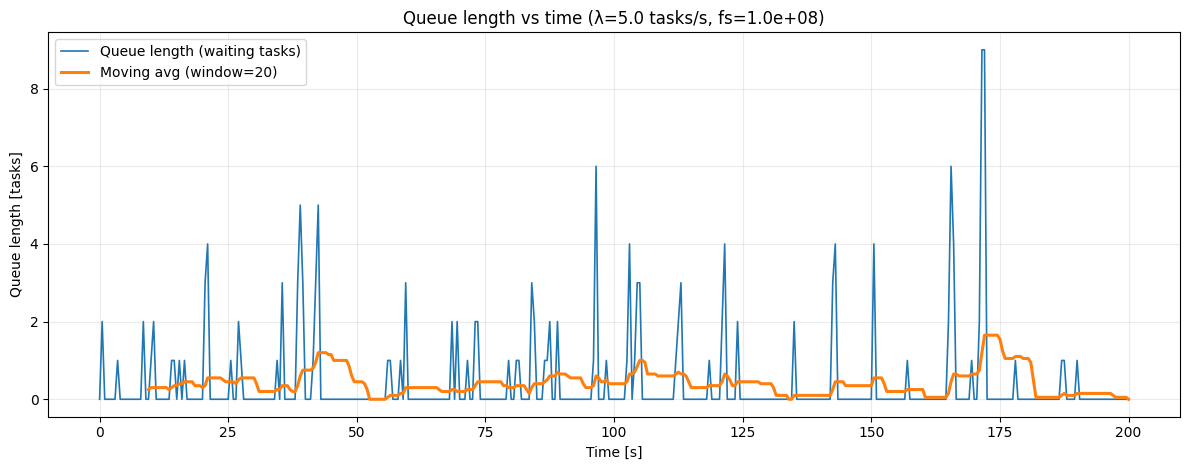

In [151]:
# --- FIFO queue "scorrimento" demo: transient -> steady-state ---
lambda_arrival = 5.0
fs = 1e8
sim_time = 200
sampling_interval = 0.5

sim = SensingNodeSimulator(lambda_arrival=lambda_arrival, fs=fs, random_seed=42)
metrics = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)

print("Simulation sanity check")
print(f"  λ = {lambda_arrival} tasks/s")
print(f"  Sim time = {sim_time}s")
print(f"  Arrivals observed = {metrics['num_arrivals']}")
print(f"  Departures observed = {metrics['num_tasks']}")
print(f"  Avg queue length (sampled) = {metrics['avg_queue_length']:.3f}")
print(f"  Avg sojourn time (completed tasks) = {metrics['avg_delay']:.4f} s")

# Plot queue length and moving average
window_size = 20
queue_lengths = np.array(metrics['queue_lengths'], dtype=float)
time_points = np.array(metrics['time_points'], dtype=float)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(time_points, queue_lengths, linewidth=1.2, label='Queue length (waiting tasks)')

if len(queue_lengths) >= window_size:
    kernel = np.ones(window_size) / window_size
    moving_avg = np.convolve(queue_lengths, kernel, mode='valid')
    moving_avg_times = time_points[window_size-1:]
    ax.plot(moving_avg_times, moving_avg, linewidth=2.2, label=f'Moving avg (window={window_size})')

ax.set_title(f'Queue length vs time (λ={lambda_arrival} tasks/s, fs={fs:.1e})')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Queue length [tasks]')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


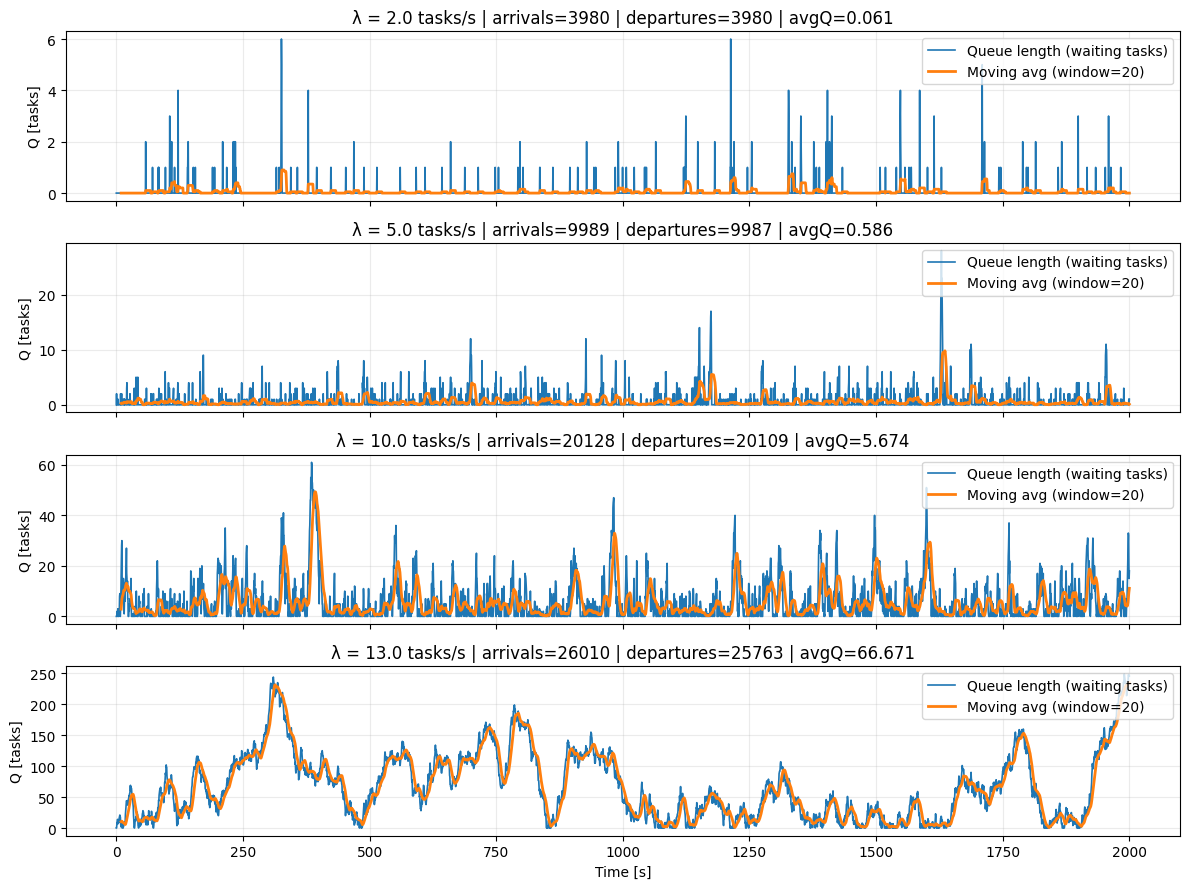


Interpretazione rapida:
- A parità di fs, aumentando λ aumenta l'utilizzazione ρ e la coda impiega più tempo a stabilizzarsi (transiente più lungo/più visibile).
- Se λ si avvicina troppo alla capacità (ρ→1), la coda media cresce molto e le fluttuazioni diventano grandi.


In [152]:
# --- Comparison: queue length for different lambdas (same model, same fs) ---
fs = 1e8
sim_time = 2000
sampling_interval = 0.5
window_size = 20

lambda_list = [2.0,5.0, 10.0, 13.0]

fig, axes = plt.subplots(len(lambda_list), 1, figsize=(12, 9), sharex=True)
if len(lambda_list) == 1:
    axes = [axes]

for ax, lam in zip(axes, lambda_list):
    sim = SensingNodeSimulator(lambda_arrival=lam, fs=fs, random_seed=42)
    m = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)

    t = np.array(m['time_points'], dtype=float)
    q = np.array(m['queue_lengths'], dtype=float)

    ax.plot(t, q, linewidth=1.2, label='Queue length (waiting tasks)')

    if len(q) >= window_size:
        kernel = np.ones(window_size) / window_size
        q_ma = np.convolve(q, kernel, mode='valid')
        t_ma = t[window_size - 1:]
        ax.plot(t_ma, q_ma, linewidth=2.0, label=f'Moving avg (window={window_size})')

    ax.set_title(f"λ = {lam} tasks/s | arrivals={m['num_arrivals']} | departures={m['num_tasks']} | avgQ={m['avg_queue_length']:.3f}")
    ax.set_ylabel('Q [tasks]')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

print("\nInterpretazione rapida:")
print("- A parità di fs, aumentando λ aumenta l'utilizzazione ρ e la coda impiega più tempo a stabilizzarsi (transiente più lungo/più visibile).")
print("- Se λ si avvicina troppo alla capacità (ρ→1), la coda media cresce molto e le fluttuazioni diventano grandi.")

Initial data removal for transient phase

Initial data removal (mean variation)
  λ = 12.0 tasks/s | fs = 1.0e+08
  n = 4001 samples | sampling_interval = 0.5s
  x̄ (global mean) = 16.1275
  k range plotted: 0 .. 3801 (min_tail=200)
  Curvature threshold = 3.564e-05  (thr_frac=0.55)
  Estimated knee: k* = 1510  =>  transient_end_time ≈ 755.0 s
  Knee method: first peak >= 0.55 * max(|d2|)


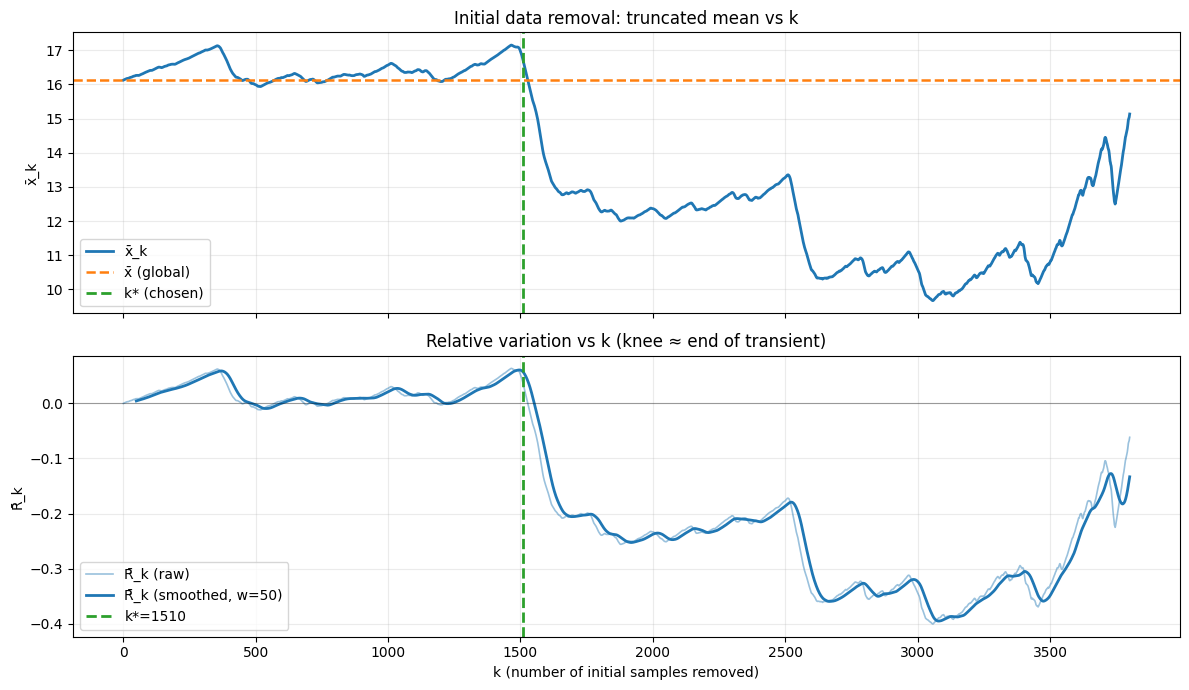


--- Metrics (full run vs steady-state after knee) ---
Full run:    avg_queue_length = 16.1275
Steady-state avg_queue_length = 16.7001  (using samples with t >= 755.0s)
Full run:    avg_delay = 1.4383 s  (over 23637 completed tasks)
Steady-state avg_delay = 1.4550 s  (over 14708 completed tasks in steady-state)

Note:
- Queue length is computed from sampled waiting-queue length after the knee.
- Delay is computed from completed tasks whose arrival time is after the knee (warm-up removed).


In [173]:
# --- Initial data removal (mean variation) + steady-state recomputation ---
# Following the slide:
# 1) x̄ = (1/n) * Σ x_j
# 2) x̄_k = (1/(n-k)) * Σ_{j=k+1..n} x_j  (mean after removing first k samples)
# 3) R̄_k = (x̄_k - x̄) / x̄              (relative variation)
# 4) Plot x̄_k or R̄_k vs k and choose the "knee" as the end of transient.
#
# Here we also estimate the knee automatically and recompute avg delay and avg queue length AFTER the knee.
# Knee rule implemented here: choose the FIRST curvature peak that exceeds a threshold.

# Some environments have LaTeX/mathtext configured in a way that can break $...$ labels.
# Force plain-text rendering for robustness.
plt.rcParams['text.usetex'] = False

fs = 1e8
lambda_for_transient = 12.0
sim_time = 2000
sampling_interval = 0.5

sim = SensingNodeSimulator(lambda_arrival=lambda_for_transient, fs=fs, random_seed=42)
metrics = sim.run_simulation(total_time=sim_time, sampling_interval=sampling_interval)

# Sampled queue length time series
x = np.array(metrics['queue_lengths'], dtype=float)
t_samples = np.array(metrics['time_points'], dtype=float)
n = len(x)

# Completed-task delay time series (per departed task)
delay = np.array(metrics.get('delay_times', []), dtype=float)
arr_completed = np.array(metrics.get('completed_arrival_times', []), dtype=float)
dep_completed = np.array(metrics.get('departure_times', []), dtype=float)

# Global mean x̄
x_bar = float(np.mean(x))

# Compute x̄_k efficiently via suffix sums: suffix_sum[k] = Σ_{j=k..n-1} x_j
suffix_sum = np.cumsum(x[::-1])[::-1]
den = np.arange(n, 0, -1, dtype=float)  # n, n-1, ..., 1
x_bar_k_all = suffix_sum / den          # x̄_k for k=0..n-1

# Avoid the last part where (n-k) is too small (noisy mean).
# min_tail is in samples (convert from seconds if you prefer)
min_tail = 200
max_k = max(0, n - min_tail)

k = np.arange(0, max_k + 1)
x_bar_k = x_bar_k_all[:max_k + 1]

# Relative variation R̄_k
if abs(x_bar) > 1e-12:
    R_bar_k = (x_bar_k - x_bar) / x_bar
else:
    R_bar_k = np.zeros_like(x_bar_k)

# --- Knee estimation (automatic) ---
# Smooth R̄_k, then use curvature (|second derivative|).
window_smooth = 50  # samples (on k-axis)
if len(R_bar_k) >= window_smooth:
    kernel = np.ones(window_smooth) / window_smooth
    R_smooth = np.convolve(R_bar_k, kernel, mode='valid')
    k_smooth = k[window_smooth - 1:]
else:
    R_smooth = R_bar_k
    k_smooth = k

# Derivatives w.r.t. k (index space)
d1 = np.gradient(R_smooth)
d2 = np.gradient(d1)
curvature = np.abs(d2)

# Search knee in a middle range to avoid edge effects
search_start = max(10, int(0.1 * len(curvature)))
search_end = min(len(curvature), int(0.8 * len(curvature)))

k_star = None
knee_method = None

if search_end > search_start:
    curv_search = curvature[search_start:search_end]

    # Threshold as a fraction of the maximum curvature in the search region.
    # Increase thr_frac to pick only very strong knees; decrease to pick earlier/softer knees.
    thr_frac = 0.55
    abs_threshold = thr_frac * float(np.max(curv_search))

    # Find the FIRST local peak above threshold
    idx_knee = None
    for j in range(1, len(curv_search) - 1):
        if curv_search[j] >= abs_threshold and curv_search[j] >= curv_search[j - 1] and curv_search[j] >= curv_search[j + 1]:
            idx_knee = search_start + j
            knee_method = f"first peak >= {thr_frac:.2f} * max(|d2|)"
            break

    # Fallback 1: first crossing (not necessarily a local peak)
    if idx_knee is None:
        above = np.where(curv_search >= abs_threshold)[0]
        if len(above) > 0:
            idx_knee = search_start + int(above[0])
            knee_method = f"first crossing >= {thr_frac:.2f} * max(|d2|)"

    # Fallback 2: max curvature (previous behavior)
    if idx_knee is None:
        idx_local = int(np.argmax(curv_search))
        idx_knee = search_start + idx_local
        knee_method = "max(|d2|) (fallback)"

    k_star = int(k_smooth[idx_knee])
else:
    abs_threshold = None

transient_end_time = (k_star * sampling_interval) if k_star is not None else None

print("Initial data removal (mean variation)")
print(f"  λ = {lambda_for_transient} tasks/s | fs = {fs:.1e}")
print(f"  n = {n} samples | sampling_interval = {sampling_interval}s")
print(f"  x̄ (global mean) = {x_bar:.4f}")
print(f"  k range plotted: 0 .. {max_k} (min_tail={min_tail})")
if abs_threshold is not None:
    print(f"  Curvature threshold = {abs_threshold:.3e}  (thr_frac={thr_frac})")
if k_star is not None:
    print(f"  Estimated knee: k* = {k_star}  =>  transient_end_time ≈ {transient_end_time:.1f} s")
    print(f"  Knee method: {knee_method}")
else:
    print("  Estimated knee: not found")

# --- Plot x̄_k and R̄_k as a function of k ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(k, x_bar_k, linewidth=2.0, label='x̄_k')
ax1.axhline(x_bar, color='tab:orange', linestyle='--', linewidth=1.8, label='x̄ (global)')
if k_star is not None:
    ax1.axvline(k_star, color='tab:green', linestyle='--', linewidth=2.0, label='k* (chosen)')
ax1.set_ylabel('x̄_k')
ax1.set_title('Initial data removal: truncated mean vs k')
ax1.grid(True, alpha=0.25)
ax1.legend(loc='best')

ax2.plot(k, R_bar_k, linewidth=1.2, alpha=0.45, label='R̄_k (raw)')
ax2.plot(k_smooth, R_smooth, linewidth=2.0, color='tab:blue', label=f'R̄_k (smoothed, w={window_smooth})')
ax2.axhline(0.0, color='k', linewidth=0.8, alpha=0.35)
if k_star is not None:
    ax2.axvline(k_star, color='tab:green', linestyle='--', linewidth=2.0, label=f'k*={k_star}')
ax2.set_xlabel('k (number of initial samples removed)')
ax2.set_ylabel('R̄_k')
ax2.set_title('Relative variation vs k (knee ≈ end of transient)')
ax2.grid(True, alpha=0.25)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

# --- Remove transient data and recompute steady-state metrics ---
if transient_end_time is None:
    print("\nSteady-state recomputation skipped: knee not found.")
else:
    # Queue length (sampled) steady-state stats
    mask_samples_ss = t_samples >= transient_end_time
    x_ss = x[mask_samples_ss]
    avg_queue_ss = float(np.mean(x_ss)) if len(x_ss) else float('nan')

    # Delay steady-state stats: keep tasks whose ARRIVAL is after transient end
    if len(delay) and len(arr_completed) == len(delay):
        mask_tasks_ss = arr_completed >= transient_end_time
        delay_ss = delay[mask_tasks_ss]
        avg_delay_ss = float(np.mean(delay_ss)) if len(delay_ss) else float('nan')
        num_tasks_ss = int(np.sum(mask_tasks_ss))
    elif len(delay) and len(dep_completed) == len(delay):
        # Fallback: if only departure times exist
        mask_tasks_ss = dep_completed >= transient_end_time
        delay_ss = delay[mask_tasks_ss]
        avg_delay_ss = float(np.mean(delay_ss)) if len(delay_ss) else float('nan')
        num_tasks_ss = int(np.sum(mask_tasks_ss))
    else:
        avg_delay_ss = float('nan')
        num_tasks_ss = 0

    print("\n--- Metrics (full run vs steady-state after knee) ---")
    print(f"Full run:    avg_queue_length = {metrics.get('avg_queue_length', float('nan')):.4f}")
    print(f"Steady-state avg_queue_length = {avg_queue_ss:.4f}  (using samples with t >= {transient_end_time:.1f}s)")

    print(f"Full run:    avg_delay = {metrics.get('avg_delay', float('nan')):.4f} s  (over {metrics.get('num_tasks', 0)} completed tasks)")
    print(f"Steady-state avg_delay = {avg_delay_ss:.4f} s  (over {num_tasks_ss} completed tasks in steady-state)")

    print("\nNote:")
    print("- Queue length is computed from sampled waiting-queue length after the knee.")
    print("- Delay is computed from completed tasks whose arrival time is after the knee (warm-up removed).")
